# Simulating the 2026 World Cup 50,000 times — an annotated rebuild

This notebook reconstructs the model behind Francisco Baquero's *Fútbol Analytics* post
[*"Mundial 2026: simulé el torneo 50.000 veces"*](https://patcheau.wordpress.com/2026/05/23/mundial-2026-simule-el-torneo-50-000-veces-y-esto-fue-lo-que-encontre/),
end to end, with the reasoning spelled out so you can see *why* each piece is built the way it is.

**The pipeline has five stages:**

1. **Data** — every international men's match since 1872 (Mart Jürisoo's public dataset).
2. **Ratings** — turn that match history into an **ELO** rating per national team.
3. **Match model** — turn two ELO ratings into probabilities: win/draw/loss, exact scorelines (Poisson), and a penalty coin.
4. **Tournament rules** — encode the *new* 48-team format (12 groups of 4, top 2 + 8 best thirds, then a 32-team knockout).
5. **Monte Carlo** — replay the whole tournament tens of thousands of times and read the frequencies as probabilities.

> A framing the author insists on, and worth keeping in mind: this is a **simulation** model, not a **forecast**.
> It does not predict a single outcome. It maps the distribution of outcomes that the historical record implies.


## A note on what's reproducible

Two parts of the original are pinned down, two parts you should expect to differ slightly:

- **Pinned:** the tournament *format* and the confirmed *group draw* (hard-coded below from the official December 2025 draw + March 2026 playoff results).
- **Approximate:** the exact ELO numbers (they depend on K-factor scales, the initial rating, and the data cut-off date) and FIFA's full third-place→bracket *lookup table* (495 possible combinations — we use a principled simplification, flagged where it happens).

So your champion percentages will land *near* the article's, not exactly on them. The qualitative story — Spain favourite, Argentina close behind, Colombia surprisingly high — is what reproduces robustly.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

# One RNG, seeded, so the whole notebook is reproducible.
SEED = 2026
rng = np.random.default_rng(SEED)

pd.set_option("display.max_rows", 60)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. The data

The starting point is the GitHub repo **`martj42/international_results`** — a public, MIT-licensed CSV
that records essentially every international men's match from Scotland–England (30 Nov 1872) to the present.
It's the de-facto standard dataset for this kind of model.

Columns we care about: `date`, `home_team`, `away_team`, `home_score`, `away_score`, `tournament`, `neutral`.

> **Network note:** this cell downloads ~50k rows over HTTP. If you're offline or behind a proxy, download
> `results.csv` from the repo manually and point `pd.read_csv` at the local file instead.


In [2]:
URL = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"

matches = pd.read_csv(URL, parse_dates=["date"])

# The author anchors the ratings at "March 2026", so we cut the history there.
# This makes the run reproducible and matches the article's reference point.
CUTOFF = pd.Timestamp("2026-06-09")
matches = matches[matches["date"] <= CUTOFF].copy()
matches = matches.dropna(subset=["home_score", "away_score"]).reset_index(drop=True)

print(f"{len(matches):,} matches from {matches['date'].min().date()} to {matches['date'].max().date()}")
matches.tail(3)

49,401 matches from 1872-11-30 to 2026-06-09


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49398,2026-06-09,Togo,Benin,5.0,1.0,Friendly,Lomé,Togo,False
49399,2026-06-09,Liberia,Sierra Leone,3.0,1.0,Friendly,Monrovia,Liberia,False
49400,2026-06-09,Iraq,Venezuela,0.0,2.0,Friendly,Bridgeview,United States,True


## 2. The ELO rating system

ELO is the chess-rating idea: every team carries a number that rises when it wins and falls when it loses,
and **the size of the move scales with how surprising the result was**. Beating a much weaker team barely
moves your rating; beating a much stronger one moves it a lot.

### The two formulas

**(a) Expected result.** Before a match, the probability team A "scores" (1 for a win, ½ for a draw) is the logistic curve

$$ W_e = \frac{1}{1 + 10^{-(R_A - R_B)/400}} $$

The `/400` is the ELO convention: a 400-point edge means ~10:1 expected dominance.

**(b) The update.** After the match,

$$ R_A \leftarrow R_A + K \cdot G \cdot (W - W_e) $$

where `W` is the actual result (1 / 0.5 / 0), `K` is the match-importance weight, and `G` is a goal-margin multiplier.
`(W - W_e)` is the *surprise*: positive if you did better than expected, negative if worse.

### The three modelling choices

- **K-factor (match importance).** A friendly is not a World Cup final. Following the article:
  `20` friendlies, `50` World Cup matches, with intermediate weights for qualifiers and continental cups.
- **Home advantage.** `+100` points added to the home side's rating *inside the expectation only* (not on neutral grounds).
- **Goal-difference multiplier `G`.** A 4–0 should count more than a 1–0 — but not four times more.
  A **logarithmic** multiplier compresses big wins: `G = 1 + ln(|goal_diff|)` (so 1→1.00, 2→1.69, 3→2.10, 4→2.39).


In [3]:
def k_factor(tournament: str) -> float:
    """Match-importance weight. Bigger K => ratings react faster to this match."""
    t = str(tournament).lower()
    if "friendly" in t:
        return 20.0
    if "fifa world cup" == t or t == "fifa world cup":
        return 50.0
    if "world cup" in t and "qual" in t:        # WC qualifiers
        return 40.0
    if "world cup" in t:                         # WC finals + related
        return 50.0
    if any(k in t for k in ["copa am", "uefa euro", "african cup",
                            "asian cup", "gold cup", "confederations"]):
        return 40.0                              # continental finals
    if "qualif" in t:                            # other qualifiers
        return 35.0
    return 30.0                                   # everything else


def goal_multiplier(goal_diff: int) -> float:
    """Logarithmic margin-of-victory weight; 1-goal games are the baseline."""
    g = abs(goal_diff)
    if g <= 1:
        return 1.0
    return 1.0 + np.log(g)


def expected_score(elo_a, elo_b, home_adv=0.0):
    """Logistic ELO expectation for team A (the /400 convention)."""
    return 1.0 / (1.0 + 10 ** (-((elo_a + home_adv) - elo_b) / 400.0))

### Building the ratings

We start everyone at **1500** (the chess convention) and walk through history match by match,
updating both teams after each game. With ~150 years of data the arbitrary starting value washes out
and the ratings settle into a meaningful spread. New teams that appear later also start at 1500.


In [4]:
HOME_FIELD = 100.0   # ELO points added to the home team's expectation
START_ELO = 1500.0

elo = defaultdict(lambda: START_ELO)

# itertuples is ~10x faster than iterrows for a loop this size.
for m in matches.itertuples(index=False):
    home, away = m.home_team, m.away_team
    hs, as_ = int(m.home_score), int(m.away_score)
    neutral = bool(m.neutral)

    ra, rb = elo[home], elo[away]
    adv = 0.0 if neutral else HOME_FIELD

    we_home = expected_score(ra, rb, adv)        # expected "score" for home
    if hs > as_:
        w_home = 1.0
    elif hs < as_:
        w_home = 0.0
    else:
        w_home = 0.5

    k = k_factor(m.tournament)
    g = goal_multiplier(hs - as_)
    delta = k * g * (w_home - we_home)

    # Zero-sum update: whatever home gains, away loses.
    elo[home] = ra + delta
    elo[away] = rb - delta

ELO = dict(elo)
print(f"Rated {len(ELO):,} national teams.")

Rated 336 national teams.


Let's look at the top of the table and eyeball it against the article
(Spain ~2238, Argentina ~2209, France ~2153, Brazil ~2091, England ~2090, Colombia ~2081).
Exact numbers will drift with the K-scale and cut-off, but the ordering near the top should look familiar.

In [5]:
ranking = (pd.Series(ELO, name="ELO")
             .sort_values(ascending=False)
             .round(0).astype(int)
             .rename_axis("team")
             .reset_index())
ranking.index += 1
ranking.head(20)

,team,ELO
1,Spain,2241
2,Argentina,2216
3,France,2158
4,England,2122
5,Brazil,2105
6,Colombia,2095
7,Portugal,2059
8,Ecuador,2052
9,Netherlands,2042
10,Germany,2035


## 3. From ratings to a match model

ELO gives us a single expectation number. A football match needs more than that — we need
**win/draw/loss** probabilities, and for the group stage we need **exact scorelines** (to break ties on
goal difference and to rank third-placed teams across groups).

### (a) Win / Draw / Loss

The trick: ELO's expected score already equals `P(win) + ½·P(draw)`. So if we model the **draw probability**
separately, the win and loss probabilities fall out.

Draws are *most* likely between evenly matched teams and rare in mismatches. We model that with an
exponential decay in the rating gap: ~30% when teams are equal, decaying toward ~8% for large gaps.


In [6]:
def draw_probability(elo_diff):
    """Draw prob as a decaying function of |rating gap|: ~0.30 equal -> ~0.08 wide."""
    return 0.08 + 0.22 * np.exp(-abs(elo_diff) / 200.0)


def wdl_probabilities(elo_a, elo_b, home_adv=0.0):
    """Return (P(A win), P(draw), P(B win)). Uses E[score] = P(win) + 0.5*P(draw)."""
    e_a = expected_score(elo_a, elo_b, home_adv)
    p_draw = draw_probability((elo_a + home_adv) - elo_b)
    p_a = e_a - 0.5 * p_draw
    p_b = 1.0 - p_draw - p_a
    p_a, p_b = max(p_a, 1e-9), max(p_b, 1e-9)   # numerical floor
    s = p_a + p_draw + p_b
    return p_a / s, p_draw / s, p_b / s

Quick sanity check — a clear favourite, and two equals:

In [7]:
for a, b in [("Spain", "Colombia"), ("Brazil", "Brazil")]:
    pa, pd_, pb = wdl_probabilities(ELO.get(a, 1800), ELO.get(b, 1800))
    print(f"{a:8} vs {b:8}:  win {pa:.2f}  draw {pd_:.2f}  loss {pb:.2f}")

Spain    vs Colombia:  win 0.61  draw 0.19  loss 0.21
Brazil   vs Brazil  :  win 0.35  draw 0.30  loss 0.35


Here's the draw curve itself — the shape that says "draws happen between equals, not in mismatches":

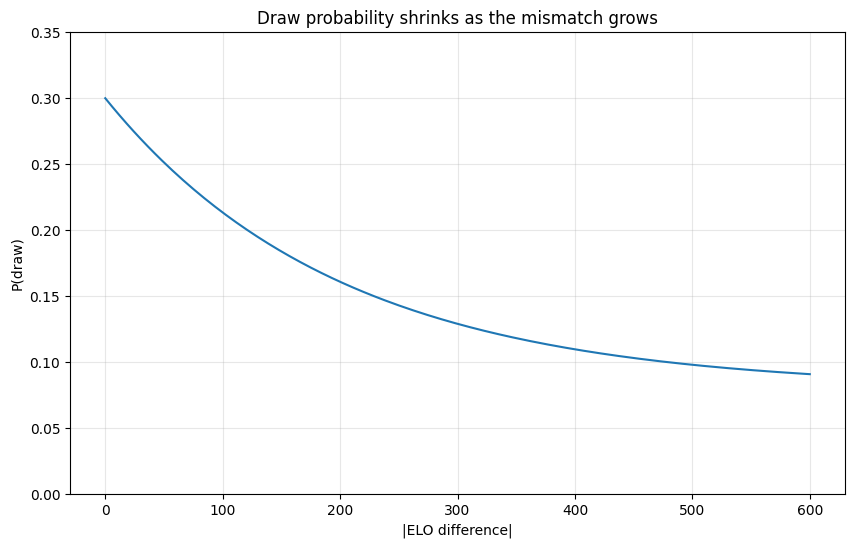

In [8]:
diffs = np.linspace(0, 600, 200)
plt.plot(diffs, [draw_probability(d) for d in diffs])
plt.xlabel("|ELO difference|")
plt.ylabel("P(draw)")
plt.title("Draw probability shrinks as the mismatch grows")
plt.ylim(0, 0.35)
plt.show()

### (b) Exact scorelines (Poisson)

Goals in football are well-approximated by a **Poisson process**: events arriving at a roughly constant rate.
So each team's goal count is `Poisson(λ)`, with the two teams' draws **independent**.

We pin the *total* expected goals to the historical average (~**2.65** per match) and split that total
between the teams according to their win expectation — the favourite gets the larger share of the goal budget.


In [9]:
GOALS_TOTAL = 2.65   # historical mean total goals per match

def simulate_scoreline(elo_a, elo_b, home_adv=0.0):
    """Independent Poisson goals; total expected goals held at GOALS_TOTAL."""
    e_a = expected_score(elo_a, elo_b, home_adv)
    share_a = 0.5 + 0.5 * (e_a - 0.5)          # gentle tilt toward the favourite
    lam_a = GOALS_TOTAL * share_a
    lam_b = GOALS_TOTAL * (1 - share_a)
    return int(rng.poisson(lam_a)), int(rng.poisson(lam_b))

### (c) The penalty coin

In the knockout, a draw goes to a shootout. Shootouts are close to a coin flip, but we tilt it
*slightly* toward the higher-rated team — capped near **52/48** in the most extreme mismatch.


In [10]:
def knockout_winner(team_a, team_b):
    """Return the winning team name. Draws are resolved by a lightly-loaded penalty coin."""
    ea, eb = ELO.get(team_a, 1700), ELO.get(team_b, 1700)
    p_a, p_draw, p_b = wdl_probabilities(ea, eb)
    u = rng.random()
    if u < p_a:
        return team_a
    if u < p_a + p_b:
        return team_b
    # penalties: coin tilted by rating, tanh keeps it bounded near 52/48
    p_pen_a = 0.5 + 0.02 * np.tanh((ea - eb) / 200.0)
    return team_a if rng.random() < p_pen_a else team_b

## 4. The 2026 format and the draw

New format, biggest in history: **48 teams, 12 groups of 4**. The top 2 of each group advance
automatically, plus the **8 best third-placed** teams — 32 teams into a brand-new Round of 32,
then straight single-elimination to the final.

Below is the **confirmed draw** (official December 2025 draw, completed by the March 2026 playoffs).
Colombia is in **Group K** with Portugal, Uzbekistan and DR Congo — exactly as the article describes.


In [11]:
GROUPS = {
    "A": ["Mexico", "South Korea", "South Africa", "Czechia"],
    "B": ["Canada", "Switzerland", "Qatar", "Bosnia and Herzegovina"],
    "C": ["Brazil", "Morocco", "Scotland", "Haiti"],
    "D": ["United States", "Paraguay", "Australia", "Turkey"],
    "E": ["Germany", "Ecuador", "Ivory Coast", "Curacao"],
    "F": ["Netherlands", "Japan", "Tunisia", "Sweden"],
    "G": ["Belgium", "Iran", "Egypt", "New Zealand"],
    "H": ["Spain", "Uruguay", "Saudi Arabia", "Cape Verde"],
    "I": ["France", "Senegal", "Norway", "Iraq"],
    "J": ["Argentina", "Austria", "Algeria", "Jordan"],
    "K": ["Portugal", "Colombia", "Uzbekistan", "DR Congo"],
    "L": ["England", "Croatia", "Panama", "Ghana"],
}
ALL_TEAMS = [t for g in GROUPS.values() for t in g]
assert len(ALL_TEAMS) == 48

# Confirm every drawn team actually has a rating (name-matching is the usual gotcha).
missing = [t for t in ALL_TEAMS if t not in ELO]
print("Teams with no ELO (will fall back to default):", missing or "none")

Teams with no ELO (will fall back to default): ['Czechia', 'Curacao']


> **Watch the names.** The dataset uses specific spellings (e.g. `Turkey`, `Czechia`, `DR Congo`, `Cape Verde`).
> If a team shows up as "missing" above, it means the draw name doesn't match the dataset name and you should
> reconcile them — otherwise that team silently gets the default rating. This is the single most common bug
> in this kind of model.

## 5. Group stage

A group is a round-robin: each of the 4 teams plays the other 3 (6 matches). Points are 3/1/0.
FIFA's tiebreakers are, in order: points → goal difference → goals scored (then head-to-head / fair-play,
which we approximate with the rating as a final deterministic tiebreak).


In [12]:
def simulate_group(teams):
    """Round-robin; returns (standings_rows, match_log).

    match_log is a list of dicts — one per fixture — recording the two teams,
    the score, and who won. We need this to compute per-fixture win rates across
    the Monte Carlo.
    """
    stats = {t: {"P": 0, "GF": 0, "GA": 0} for t in teams}
    match_log = []

    for i in range(len(teams)):
        for j in range(i + 1, len(teams)):
            a, b = teams[i], teams[j]
            ga, gb = simulate_scoreline(ELO.get(a, 1700), ELO.get(b, 1700))

            # record before updating stats so the log is always complete
            if ga > gb:   result = a
            elif gb > ga: result = b
            else:         result = "draw"
            match_log.append({"home": a, "away": b,
                               "home_goals": ga, "away_goals": gb,
                               "winner": result})

            stats[a]["GF"] += ga; stats[a]["GA"] += gb
            stats[b]["GF"] += gb; stats[b]["GA"] += ga
            if ga > gb:   stats[a]["P"] += 3
            elif gb > ga: stats[b]["P"] += 3
            else:         stats[a]["P"] += 1; stats[b]["P"] += 1

    def sort_key(t):
        s = stats[t]
        return (s["P"], s["GF"] - s["GA"], s["GF"], ELO.get(t, 1700))

    ordered = sorted(teams, key=sort_key, reverse=True)
    rows = [{"team": t, "rank": r, "P": stats[t]["P"],
             "GD": stats[t]["GF"] - stats[t]["GA"], "GF": stats[t]["GF"]}
            for r, t in enumerate(ordered, 1)]
    return rows, match_log


def simulate_all_groups():
    """Returns: firsts, seconds, thirds (unchanged), plus group_logs dict."""
    firsts, seconds, thirds = {}, {}, []
    group_logs = {}
    for g, teams in GROUPS.items():
        rows, match_log = simulate_group(teams)
        firsts[g] = rows[0]["team"]
        seconds[g] = rows[1]["team"]
        thirds.append({"group": g, **rows[2]})
        group_logs[g] = match_log
    return firsts, seconds, thirds, group_logs


### Ranking the third-placed teams

This is the genuinely new wrinkle. All 12 third-placed teams are pooled and ranked by the same criteria
(points → GD → goals). The **top 8 advance**; the bottom 4 go home. Because GD is the first tiebreaker,
a third-placed team has a real incentive to *run up the score* — a 3–0 third place beats a 1–0 third place.


In [13]:
def best_eight_thirds(thirds):
    ordered = sorted(thirds,
                     key=lambda r: (r["P"], r["GD"], r["GF"], ELO.get(r["team"], 1700)),
                     reverse=True)
    return ordered[:8]

## 6. The knockout bracket

From the Round of 16 onward the bracket is an ordinary single-elimination tree (16→8→4→2→1).
The **Round of 32** is where the new format gets fiddly: FIFA uses a *predetermined lookup table* to
decide which group winner each qualifying third-placed team faces, and that table has one row for each of
the C(12,8)=495 possible combinations of which groups produce the 8 thirds.

**Our simplification (flagged honestly):** FIFA's published high-level rule is that the winners of groups
**A, B, D, E, G, I, K, L** are paired against the 8 third-placed teams, while the winners of **C, F, H, J**
play runners-up. We follow exactly that structure and assign the 8 qualifying thirds to those eight
"winner-vs-third" slots by their rank. This reproduces the *shape* of the bracket faithfully; it won't match
FIFA's exact seat-by-seat allocation, but it doesn't change the qualitative results. This is the one place
the model deviates from the official rules, and it's a reasonable, transparent approximation.


In [14]:
WINNERS_VS_THIRD  = ["A", "B", "D", "E", "G", "I", "K", "L"]   # face a 3rd-placed team
WINNERS_VS_RUNNER = ["C", "F", "H", "J"]                       # face a runner-up

R32_TEMPLATE = [
    ("W_A", "T1"), ("W_C", "R_D"),
    ("W_E", "T2"), ("W_G", "R_H"),
    ("W_I", "T3"), ("W_K", "R_L"),
    ("W_B", "T4"), ("W_F", "R_A"),
    ("W_L", "T5"), ("W_J", "R_E"),
    ("W_D", "T6"), ("W_H", "R_B"),
    ("R_C", "T7"), ("R_F", "R_I"),
    ("R_G", "T8"), ("R_J", "R_K"),
]

def build_slots(firsts, seconds, thirds8):
    slots = {}
    for g in GROUPS:
        slots[f"W_{g}"] = firsts[g]
        slots[f"R_{g}"] = seconds[g]
    for i, row in enumerate(thirds8, 1):
        slots[f"T{i}"] = row["team"]
    return slots

def pair_up(lst):
    """Adjacent winners form the next round's matches: [0v1, 2v3, ...]."""
    return [(lst[i], lst[i + 1]) for i in range(0, len(lst), 2)]

def play_and_log(pairs, round_name, ko_log):
    """Play every match in a round, log the result, return the list of winners.

    ko_log is mutated in-place so we accumulate across rounds without returning
    a new structure each time.
    """
    winners, log = [], []
    for a, b in pairs:
        w = knockout_winner(a, b)
        log.append({"home": a, "away": b, "winner": w,
                    "loser": b if w == a else a})
        winners.append(w)
    ko_log[round_name] = log
    return winners

def simulate_knockout(firsts, seconds, thirds8):
    slots = build_slots(firsts, seconds, thirds8)
    r32_pairs = [(slots[x], slots[y]) for x, y in R32_TEMPLATE]
    ko_log = {}

    reached_r32   = [t for pair in r32_pairs for t in pair]
    reached_r16   = play_and_log(r32_pairs,            "r32",   ko_log)
    reached_qf    = play_and_log(pair_up(reached_r16), "r16",   ko_log)
    reached_sf    = play_and_log(pair_up(reached_qf),  "qf",    ko_log)
    reached_final = play_and_log(pair_up(reached_sf),  "sf",    ko_log)
    champ_list    = play_and_log(pair_up(reached_final),"final", ko_log)

    return {"r32": reached_r32, "r16": reached_r16, "qf": reached_qf,
            "sf": reached_sf, "final": reached_final,
            "champion": champ_list[0], "ko_log": ko_log}


## 7. One full tournament

Let's run a single tournament first, to see all the pieces click together before we scale up.


In [15]:
firsts, seconds, thirds, group_logs = simulate_all_groups()
thirds8 = best_eight_thirds(thirds)
ko = simulate_knockout(firsts, seconds, thirds8)

print("Group K  ->  winner:", firsts["K"], "| runner-up:", seconds["K"])
print()
print("Group K fixtures (one simulation):")
for m in group_logs["K"]:
    print(f"  {m['home']:25} {m['home_goals']} - {m['away_goals']}  {m['away']}")
print()
print("Qualifying 3rds:", [r["team"] for r in thirds8])
print("Semifinalists:", ko["sf"])
print("Finalists:", ko["final"])
print("CHAMPION:", ko["champion"])


Group K  ->  winner: Colombia | runner-up: Portugal

Group K fixtures (one simulation):
  Portugal                  0 - 5  Colombia
  Portugal                  2 - 2  Uzbekistan
  Portugal                  1 - 0  DR Congo
  Colombia                  3 - 0  Uzbekistan
  Colombia                  1 - 0  DR Congo
  Uzbekistan                1 - 1  DR Congo

Qualifying 3rds: ['Australia', 'Tunisia', 'Bosnia and Herzegovina', 'Scotland', 'Mexico', 'Egypt', 'Ghana', 'Curacao']
Semifinalists: ['Spain', 'Senegal', 'Croatia', 'Brazil']
Finalists: ['Spain', 'Croatia']
CHAMPION: Spain


## 8. Monte Carlo — replay the tournament many times

One tournament tells us nothing; the randomness swamps it. The whole point is to replay the bracket
**N times** and read each team's *frequency* of reaching each stage as its *probability*.

We track six milestones per team: reaching the **Round of 32** (= advancing from the group),
**Round of 16, Quarterfinals, Semifinals, Final**, and being **Champion**.

> **Runtime:** each tournament is ~100 simulated matches. `N = 50_000` (the article's number) is a few minutes
> of pure Python. Start with `N = 10_000` to iterate quickly, then bump it up for the final run.


In [16]:
def monte_carlo(n=10_000, progress_every=2_000):
    rounds = ["r32", "r16", "qf", "sf", "final", "champion"]
    counts = {t: {r: 0 for r in rounds} for t in ALL_TEAMS}

    # Group-stage match tallies.
    # grp_results[a][b] = {"win": int, "draw": int, "loss": int}
    # meaning: in simulations where a played b in the group stage,
    #          a won `win` times, drew `draw` times, lost `loss` times.
    grp_results  = defaultdict(lambda: defaultdict(lambda: {"win": 0, "draw": 0, "loss": 0}))

    # Knockout head-to-head: ko_results[a][b] = times a beat b in any KO round.
    # We also track which round each KO encounter happened in.
    ko_results   = defaultdict(lambda: defaultdict(int))
    ko_by_round  = defaultdict(lambda: defaultdict(lambda: defaultdict(int)))
    # ko_by_round[round][winner][loser] = count

    for i in range(n):
        firsts, seconds, thirds, group_logs = simulate_all_groups()
        thirds8 = best_eight_thirds(thirds)
        ko = simulate_knockout(firsts, seconds, thirds8)

        # --- group match tallies ---
        for g_log in group_logs.values():
            for m in g_log:
                a, b = m["home"], m["away"]
                w = m["winner"]
                if w == a:
                    grp_results[a][b]["win"]  += 1
                    grp_results[b][a]["loss"] += 1
                elif w == b:
                    grp_results[b][a]["win"]  += 1
                    grp_results[a][b]["loss"] += 1
                else:
                    grp_results[a][b]["draw"] += 1
                    grp_results[b][a]["draw"] += 1

        # --- knockout match tallies ---
        for round_name, round_log in ko["ko_log"].items():
            for m in round_log:
                winner, loser = m["winner"], m["loser"]
                ko_results[winner][loser] += 1
                ko_by_round[round_name][winner][loser] += 1

        # --- round reach counts (unchanged) ---
        for t in set(ko["r32"]):   counts[t]["r32"]   += 1
        for t in set(ko["r16"]):   counts[t]["r16"]   += 1
        for t in set(ko["qf"]):    counts[t]["qf"]    += 1
        for t in set(ko["sf"]):    counts[t]["sf"]    += 1
        for t in set(ko["final"]): counts[t]["final"] += 1
        counts[ko["champion"]]["champion"] += 1

        if progress_every and (i + 1) % progress_every == 0:
            print(f"  ...{i + 1:,} / {n:,} tournaments")

    probs = pd.DataFrame(counts).T[rounds] / n
    return (probs.sort_values("champion", ascending=False),
            grp_results, ko_results, ko_by_round)


N = 10_000   # bump to 50_000 to match the article; expect a few minutes
results, grp_results, ko_results, ko_by_round = monte_carlo(N)
print("done.")


  ...2,000 / 10,000 tournaments
  ...4,000 / 10,000 tournaments
  ...6,000 / 10,000 tournaments
  ...8,000 / 10,000 tournaments
  ...10,000 / 10,000 tournaments
done.


### Who wins the World Cup?

In [17]:
champ = (results["champion"] * 100).round(1)
top15 = champ.head(15).rename("Champion %").to_frame()
top15.index.name = "team"
top15

,Champion %
team,
Spain,25.7
Argentina,18.2
France,11.5
England,6.5
Brazil,6.3
Colombia,5.0
Portugal,3.3
Ecuador,2.8
Netherlands,2.7


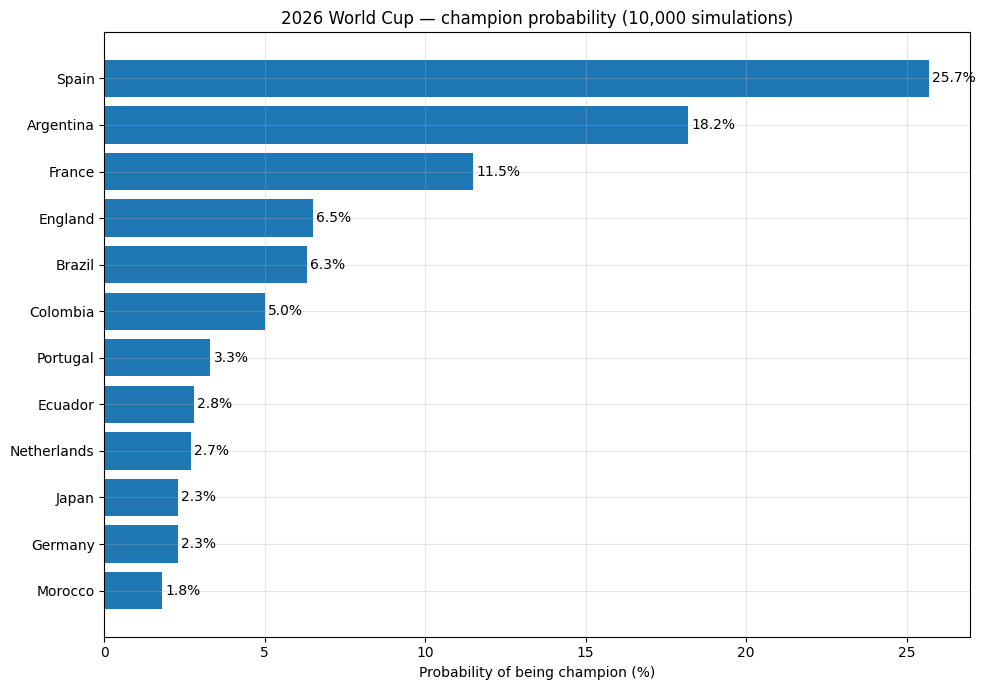

In [18]:
top12 = champ.head(12)[::-1]
plt.figure(figsize=(10, 7))
bars = plt.barh(top12.index, top12.values)
plt.xlabel("Probability of being champion (%)")
plt.title(f"2026 World Cup — champion probability ({N:,} simulations)")
for b, v in zip(bars, top12.values):
    plt.text(v + 0.1, b.get_y() + b.get_height() / 2, f"{v:.1f}%", va="center")
plt.tight_layout()
plt.show()

## 9. Colombia's path, round by round

The article's centrepiece: how far does Colombia go? We read the milestone probabilities straight off
the Monte Carlo table. Expect a monotonic decay — each round is strictly harder to reach than the last.


In [19]:
labels = {"r32": "Advance from group", "r16": "Round of 16", "qf": "Quarterfinals",
          "sf": "Semifinals", "final": "Final", "champion": "Champion"}

col = (results.loc["Colombia"] * 100).round(1)
col.index = [labels[k] for k in col.index]
col.to_frame("Colombia %")

,Colombia %
Advance from group,87.4
Round of 16,58.2
Quarterfinals,36.4
Semifinals,22.4
Final,11.3
Champion,5.0


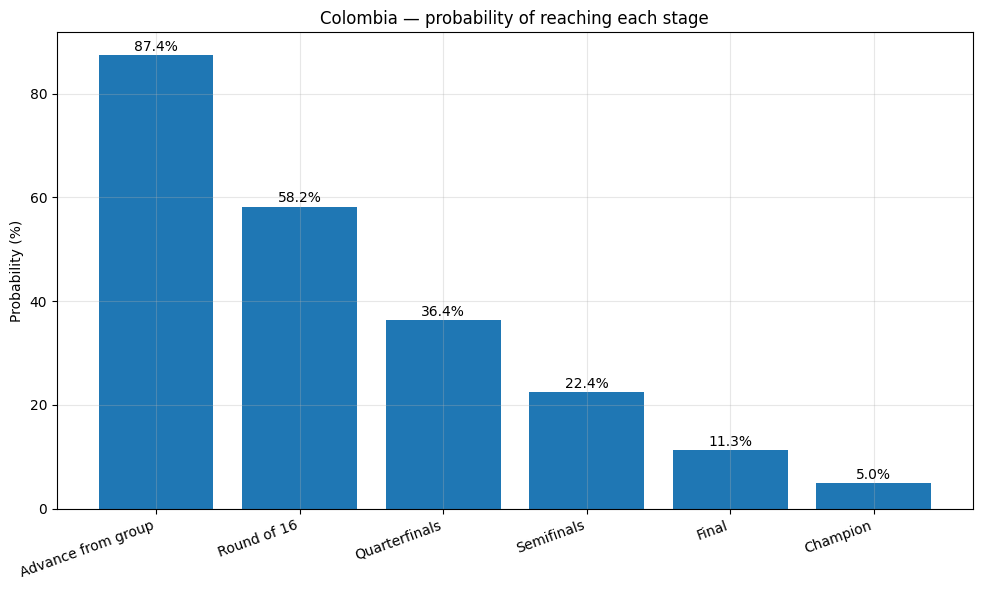

In [20]:
vals = (results.loc["Colombia"] * 100)
plt.figure(figsize=(10, 6))
order = ["r32", "r16", "qf", "sf", "final", "champion"]
plt.bar([labels[k] for k in order], [vals[k] for k in order])
plt.ylabel("Probability (%)")
plt.title("Colombia — probability of reaching each stage")
plt.xticks(rotation=20, ha="right")
for i, k in enumerate(order):
    plt.text(i, vals[k] + 0.8, f"{vals[k]:.1f}%", ha="center")
plt.tight_layout()
plt.show()

You can pull the same path for any team by changing the name:

In [21]:
def path(team):
    s = (results.loc[team] * 100).round(1)
    s.index = [labels[k] for k in s.index]
    return s.to_frame(f"{team} %")

path("Spain")

,Spain %
Advance from group,94.4
Round of 16,82.4
Quarterfinals,68.1
Semifinals,48.5
Final,36.0
Champion,25.7


## 11. Match-level breakdown

The analysis below reads directly from the tallies accumulated during the Monte Carlo.
No new simulation is needed — we just slice the counters.

### Group stage — fixture probabilities
`group_match_probs(group)` shows win/draw/loss percentages for every fixture in a group,
averaged over all `N` simulations. The numbers reflect the *pre-match* model probabilities
smoothed by `N` runs of Poisson noise, so they're slightly noisier than calling
`wdl_probabilities` directly — but they're grounded in the same model.


In [22]:
def group_match_probs(group_name):
    """Win/draw/loss % for every fixture in a group, averaged over the Monte Carlo."""
    teams = GROUPS[group_name]
    rows = []
    for i in range(len(teams)):
        for j in range(i + 1, len(teams)):
            a, b = teams[i], teams[j]
            r = grp_results[a][b]
            played = r["win"] + r["draw"] + r["loss"]
            if played == 0:
                continue
            rows.append({
                "fixture":       f"{a}  vs  {b}",
                f"{a} win %":   round(100 * r["win"]  / played, 1),
                "draw %":        round(100 * r["draw"] / played, 1),
                f"{b} win %":   round(100 * r["loss"] / played, 1),
            })
    return pd.DataFrame(rows).set_index("fixture")


# All three fixtures in Group K (Colombia's group)
group_match_probs("K")


,Portugal win %,draw %,Colombia win %,Uzbekistan win %,DR Congo win %
fixture,,,,,
Portugal vs Colombia,33.1,26.8,40.1,NaN,NaN
Portugal vs Uzbekistan,55.6,23.9,NaN,20.5,NaN
Portugal vs DR Congo,58.7,23.4,NaN,NaN,17.9
Colombia vs Uzbekistan,NaN,23.4,57.5,19.1,NaN
Colombia vs DR Congo,NaN,21.8,61.1,NaN,17.1
Uzbekistan vs DR Congo,NaN,26.7,NaN,43.1,30.2


In [23]:
# You can inspect any group — e.g. the "group of death"
group_match_probs("I")   # France / Senegal / Norway / Iraq


,France win %,draw %,Senegal win %,Norway win %,Iraq win %
fixture,,,,,
France vs Senegal,55.6,24.0,20.4,NaN,NaN
France vs Norway,50.0,24.7,NaN,25.3,NaN
France vs Iraq,63.5,21.6,NaN,NaN,14.9
Senegal vs Norway,NaN,26.5,30.8,42.7,NaN
Senegal vs Iraq,NaN,24.5,52.7,NaN,22.8
Norway vs Iraq,NaN,23.3,NaN,57.0,19.7


### Knockout stage — head-to-head across all rounds
`ko_h2h(team)` shows every opponent `team` faced in the knockout rounds across all
`N` simulations, how many times they met, and the win rate. This answers: *when Colombia
reached the knockout, who did they tend to meet — and how often did they advance?*


In [24]:
def ko_h2h(team):
    """How team fared against each opponent across all knockout encounters."""
    if not ko_results[team] and not any(team in v for v in ko_results.values()):
        print(f"{team} never appeared in the knockout in these simulations.")
        return pd.DataFrame()
    rows = []
    all_opps = set(ko_results[team].keys()) | {o for o,v in ko_results.items() if team in v}
    for opp in sorted(all_opps, key=lambda o: -(ko_results[team].get(o,0) + ko_results[o].get(team,0))):
        wins   = ko_results[team].get(opp, 0)
        losses = ko_results[opp].get(team, 0)
        total  = wins + losses
        if total == 0:
            continue
        rows.append({
            "opponent":   opp,
            "meetings":   total,
            "win %":      round(100 * wins   / total, 1),
            "loss %":     round(100 * losses / total, 1),
        })
    return pd.DataFrame(rows).set_index("opponent")


ko_h2h("Colombia")


,meetings,win %,loss %
opponent,,,
France,1807,40.1,59.9
Croatia,1697,62.5,37.5
England,1685,44.9,55.1
Argentina,1333,33.2,66.8
Panama,1251,80.7,19.3
Austria,1017,74.7,25.3
Algeria,976,74.3,25.7
Spain,860,29.8,70.2
Norway,851,62.7,37.3


In [25]:
ko_h2h("Spain")


,meetings,win %,loss %
opponent,,,
Argentina,2742,54.9,45.1
Canada,2316,86.4,13.6
Switzerland,2315,82.9,17.1
England,1618,67.1,32.9
Belgium,1601,81.2,18.8
Turkey,1550,79.9,20.1
France,1398,62.4,37.6
Ecuador,1345,74.8,25.2
Bosnia and Herzegovina,1333,96.2,3.8


### Knockout encounters broken down by round
`ko_round_detail(team)` shows the same data split by round — useful for seeing
*where* in the bracket a team's journey typically ended.


In [26]:
ROUND_LABELS = {
    "r32": "Round of 32", "r16": "Round of 16",
    "qf":  "Quarterfinal", "sf":  "Semifinal", "final": "Final",
}
ROUND_ORDER = list(ROUND_LABELS.values())

def ko_round_detail(team):
    """Per-round KO record: who team beat and who knocked them out, in bracket order."""
    rows = []
    for rnd, label in ROUND_LABELS.items():
        for opp, cnt in ko_by_round[rnd][team].items():
            rows.append({"round": label, "result": "Win",  "opponent": opp, "count": cnt})
        for winner, losers in ko_by_round[rnd].items():
            if team in losers:
                rows.append({"round": label, "result": "Loss", "opponent": winner, "count": losers[team]})
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    df["round"] = pd.Categorical(df["round"], categories=ROUND_ORDER, ordered=True)
    return (df.sort_values(["round", "result", "count"], ascending=[True, True, False])
              .reset_index(drop=True))


ko_round_detail("Colombia")


,round,result,opponent,count
0,Round of 32,Loss,England,750
1,Round of 32,Loss,Croatia,571
2,Round of 32,Loss,Argentina,446
3,Round of 32,Loss,Austria,227
4,Round of 32,Loss,Algeria,224
...,...,...,...,...
375,Final,Win,Ivory Coast,1
376,Final,Win,Haiti,1
377,Final,Win,Czechia,1
378,Final,Win,Scotland,1


C:\Users\luiscarlos.gaitan\AppData\Local\Temp\ipykernel_57332\774823457.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wins_df  = detail[detail["result"] == "Win"].groupby("round")["count"].sum()
C:\Users\luiscarlos.gaitan\AppData\Local\Temp\ipykernel_57332\774823457.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  losses_df = detail[detail["result"] == "Loss"].groupby("round")["count"].sum()


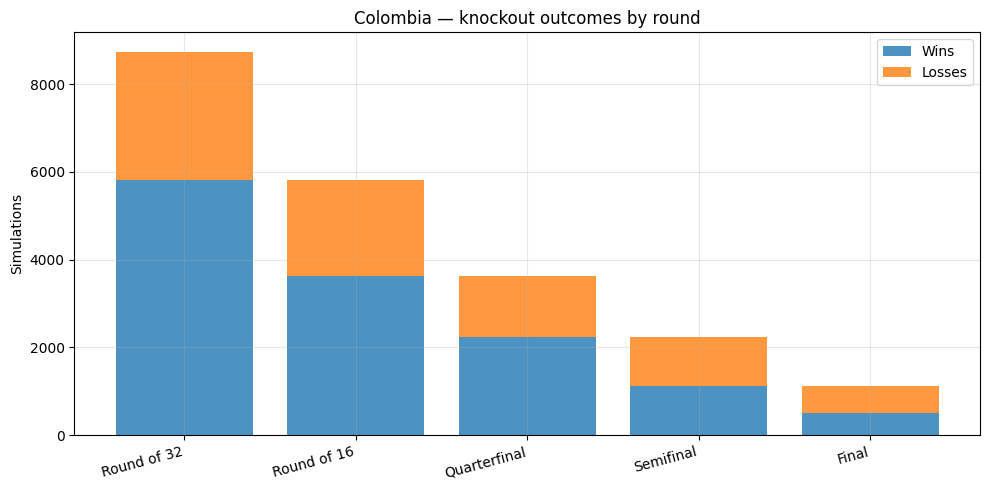

In [27]:
# Bar chart: Colombia's most common KO opponents by round
detail = ko_round_detail("Colombia")
if not detail.empty:
    wins_df  = detail[detail["result"] == "Win"].groupby("round")["count"].sum()
    losses_df = detail[detail["result"] == "Loss"].groupby("round")["count"].sum()
    rnd_order = list(ROUND_LABELS.values())
    w = [wins_df.get(r, 0) for r in rnd_order]
    l = [losses_df.get(r, 0) for r in rnd_order]

    x = range(len(rnd_order))
    plt.figure(figsize=(10, 5))
    plt.bar(x, w, label="Wins", alpha=0.8)
    plt.bar(x, l, bottom=w, label="Losses", alpha=0.8)
    plt.xticks(x, rnd_order, rotation=15, ha="right")
    plt.ylabel("Simulations")
    plt.title("Colombia — knockout outcomes by round")
    plt.legend()
    plt.tight_layout()
    plt.show()


---
## 12. Backtesting the model — World Cups 1994 to 2022

Generating plausible-looking numbers for 2026 is easy. The hard question is:
*does the model actually add value over a coin flip?*

The only honest way to answer that is to **re-run the model on historical tournaments
where we know what happened**, freeze the ELO ratings at the eve of each tournament
(so we don't use any information that wasn't available at the time), simulate the
tournament N times, and score the champion probability against reality.

### Two levels of fidelity

| | Option B (simple) | Option A (full) |
|---|---|---|
| Group stage | Randomly-seeded bracket — no groups | Real historical groups, Poisson simulation |
| Format | Generic N-round knockout | Each WC's actual format (32-team 1998–2022) |
| Scope | 1994 – 2022 (8 tournaments) | 1998 – 2022 (7 tournaments, 32-team era) |
| Main use | Quick calibration signal | Full structural test |

We include 1994 in Option B because the 3-point rule was introduced there (confirming the
same incentive structure our model assumes). Option A covers the uniform 32-team era.

### Scoring metrics

Three complementary numbers per tournament:

- **Brier score** — `(1/N) × Σᵢ (pᵢ − oᵢ)²` where `oᵢ = 1` for the actual champion, 0 otherwise.
  Lower is better. A perfectly uniform model scores ~0.030; a perfect oracle scores 0.
- **Champion rank** — the model's ELO ranking of the actual champion (1 = favourite).
  Tells you whether the model at least *knew* who the likely winner was.
- **Log score** — `−log(p_champion)`. Penalises confidently wrong predictions more harshly.
  Lower is better.


In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# Historical World Cup data
# Groups are encoded using the spellings in the martj42 dataset.
# A NAME_FIX dict below handles the most common historical mismatches.
# ─────────────────────────────────────────────────────────────────────────────

WC_HISTORY = {
    # 1994 — 24 teams, 6 groups; only used in Option B (different format)
    1994: {
        "cutoff":   "1994-05-15",
        "start":    "1994-06-17",
        "champion": "Brazil",
        "n_teams":  24,
        "format":   "24-team",
        "groups": {
            "A": ["United States", "Switzerland", "Colombia", "Romania"],
            "B": ["Cameroon", "Sweden", "Russia", "Brazil"],
            "C": ["Germany", "Bolivia", "Spain", "South Korea"],
            "D": ["Argentina", "Greece", "Nigeria", "Bulgaria"],
            "E": ["Italy", "Republic of Ireland", "Norway", "Mexico"],
            "F": ["Belgium", "Morocco", "Netherlands", "Saudi Arabia"],
        },
    },
    1998: {
        "cutoff":   "1998-05-15",
        "start":    "1998-06-10",
        "champion": "France",
        "n_teams":  32,
        "format":   "32-team",
        "groups": {
            "A": ["Brazil", "Scotland", "Morocco", "Norway"],
            "B": ["Italy", "Chile", "Cameroon", "Austria"],
            "C": ["France", "South Africa", "Saudi Arabia", "Denmark"],
            "D": ["Spain", "Nigeria", "Paraguay", "Bulgaria"],
            "E": ["South Korea", "Belgium", "Netherlands", "Mexico"],
            "F": ["Germany", "United States", "Yugoslavia", "Iran"],
            "G": ["Romania", "Colombia", "England", "Tunisia"],
            "H": ["Argentina", "Japan", "Jamaica", "Croatia"],
        },
    },
    2002: {
        "cutoff":   "2002-05-15",
        "start":    "2002-05-31",
        "champion": "Brazil",
        "n_teams":  32,
        "format":   "32-team",
        "groups": {
            "A": ["France", "Senegal", "Uruguay", "Denmark"],
            "B": ["Spain", "Slovenia", "Paraguay", "South Africa"],
            "C": ["Brazil", "Turkey", "China PR", "Costa Rica"],
            "D": ["South Korea", "United States", "Portugal", "Poland"],
            "E": ["Germany", "Saudi Arabia", "Republic of Ireland", "Cameroon"],
            "F": ["Argentina", "Nigeria", "England", "Sweden"],
            "G": ["Italy", "Ecuador", "Croatia", "Mexico"],
            "H": ["Japan", "Belgium", "Russia", "Tunisia"],
        },
    },
    2006: {
        "cutoff":   "2006-05-15",
        "start":    "2006-06-09",
        "champion": "Italy",
        "n_teams":  32,
        "format":   "32-team",
        "groups": {
            "A": ["Germany", "Costa Rica", "Poland", "Ecuador"],
            "B": ["England", "Paraguay", "Trinidad and Tobago", "Sweden"],
            "C": ["Argentina", "Ivory Coast", "Serbia and Montenegro", "Netherlands"],
            "D": ["Mexico", "Iran", "Angola", "Portugal"],
            "E": ["Italy", "Ghana", "United States", "Czech Republic"],
            "F": ["Brazil", "Croatia", "Australia", "Japan"],
            "G": ["France", "Switzerland", "South Korea", "Togo"],
            "H": ["Spain", "Ukraine", "Tunisia", "Saudi Arabia"],
        },
    },
    2010: {
        "cutoff":   "2010-05-15",
        "start":    "2010-06-11",
        "champion": "Spain",
        "n_teams":  32,
        "format":   "32-team",
        "groups": {
            "A": ["South Africa", "Mexico", "Uruguay", "France"],
            "B": ["Argentina", "Nigeria", "South Korea", "Greece"],
            "C": ["England", "United States", "Algeria", "Slovenia"],
            "D": ["Germany", "Australia", "Serbia", "Ghana"],
            "E": ["Netherlands", "Denmark", "Japan", "Cameroon"],
            "F": ["Italy", "Paraguay", "New Zealand", "Slovakia"],
            "G": ["Brazil", "North Korea", "Ivory Coast", "Portugal"],
            "H": ["Spain", "Switzerland", "Honduras", "Chile"],
        },
    },
    2014: {
        "cutoff":   "2014-05-15",
        "start":    "2014-06-12",
        "champion": "Germany",
        "n_teams":  32,
        "format":   "32-team",
        "groups": {
            "A": ["Brazil", "Croatia", "Mexico", "Cameroon"],
            "B": ["Spain", "Netherlands", "Chile", "Australia"],
            "C": ["Colombia", "Greece", "Ivory Coast", "Japan"],
            "D": ["Uruguay", "Costa Rica", "England", "Italy"],
            "E": ["Switzerland", "Ecuador", "France", "Honduras"],
            "F": ["Argentina", "Bosnia and Herzegovina", "Iran", "Nigeria"],
            "G": ["Germany", "Portugal", "Ghana", "United States"],
            "H": ["Belgium", "Algeria", "Russia", "South Korea"],
        },
    },
    2018: {
        "cutoff":   "2018-05-15",
        "start":    "2018-06-14",
        "champion": "France",
        "n_teams":  32,
        "format":   "32-team",
        "groups": {
            "A": ["Russia", "Saudi Arabia", "Egypt", "Uruguay"],
            "B": ["Portugal", "Spain", "Morocco", "Iran"],
            "C": ["France", "Australia", "Peru", "Denmark"],
            "D": ["Argentina", "Iceland", "Croatia", "Nigeria"],
            "E": ["Brazil", "Switzerland", "Costa Rica", "Serbia"],
            "F": ["Germany", "Mexico", "Sweden", "South Korea"],
            "G": ["Belgium", "Panama", "Tunisia", "England"],
            "H": ["Poland", "Senegal", "Colombia", "Japan"],
        },
    },
    2022: {
        "cutoff":   "2022-10-31",
        "start":    "2022-11-20",
        "champion": "Argentina",
        "n_teams":  32,
        "format":   "32-team",
        "groups": {
            "A": ["Qatar", "Ecuador", "Senegal", "Netherlands"],
            "B": ["England", "Iran", "United States", "Wales"],
            "C": ["Argentina", "Saudi Arabia", "Mexico", "Poland"],
            "D": ["France", "Australia", "Denmark", "Tunisia"],
            "E": ["Spain", "Costa Rica", "Germany", "Japan"],
            "F": ["Belgium", "Canada", "Morocco", "Croatia"],
            "G": ["Brazil", "Serbia", "Switzerland", "Cameroon"],
            "H": ["Portugal", "Ghana", "Uruguay", "South Korea"],
        },
    },
}

# Name normalisation: map dataset spellings → our WC_HISTORY spellings.
# The martj42 dataset has evolved over time; this covers the common mismatches.
HIST_NAME_FIX = {
    "Czech Republic":       "Czech Republic",   # used pre-2016 rebranding
    "Czechia":              "Czech Republic",
    "IR Iran":              "Iran",
    "Korea Republic":       "South Korea",
    "Korea DPR":            "North Korea",
    "China":                "China PR",
    "Republic of Ireland":  "Republic of Ireland",
    "Wales":                "Wales",
    "Yugoslavia":           "Yugoslavia",
    "Serbia and Montenegro":"Serbia and Montenegro",
    "Trinidad & Tobago":    "Trinidad and Tobago",
    "Ivory Coast":          "Ivory Coast",
    "Bosnia & Herzegovina": "Bosnia and Herzegovina",
}

print("Historical WC data loaded:", list(WC_HISTORY.keys()))


Historical WC data loaded: [1994, 1998, 2002, 2006, 2010, 2014, 2018, 2022]


### Computing frozen ELO ratings

For a fair backtest we must **re-run the ELO computation from scratch using only matches
up to the eve of each tournament**. Using the 2026 ELO (which has seen all the
subsequent matches) would be data leakage.

The function below is a self-contained replay of the main ELO loop, parameterised by
`cutoff_date`. We also accept a `name_fix` dict so that historical spellings in the
dataset are mapped to our canonical names before the loop runs.


In [29]:
def compute_elo_at_cutoff(matches_df, cutoff_date, name_fix=None):
    """Replay the full ELO loop on matches up to cutoff_date.

    Parameters
    ----------
    matches_df  : the full martj42 DataFrame (all years)
    cutoff_date : str or pd.Timestamp — only matches on or before this date are used
    name_fix    : optional dict mapping raw dataset names → canonical names

    Returns
    -------
    dict  team_name -> float ELO rating
    """
    sub = matches_df[matches_df["date"] <= pd.Timestamp(cutoff_date)].copy()
    if name_fix:
        for col in ("home_team", "away_team"):
            sub[col] = sub[col].replace(name_fix)

    elo = defaultdict(lambda: 1500.0)
    for m in sub.itertuples(index=False):
        home, away = m.home_team, m.away_team
        hs, as_ = int(m.home_score), int(m.away_score)
        neutral = bool(m.neutral)
        ra, rb = elo[home], elo[away]
        adv = 0.0 if neutral else HOME_FIELD
        we = expected_score(ra, rb, adv)
        w  = 1.0 if hs > as_ else (0.0 if hs < as_ else 0.5)
        delta = k_factor(m.tournament) * goal_multiplier(hs - as_) * (w - we)
        elo[home] = ra + delta
        elo[away] = rb - delta

    return dict(elo)


# Quick smoke-test on the current dataset
test_elo = compute_elo_at_cutoff(matches, "2022-11-01")
top5 = sorted(test_elo.items(), key=lambda x: -x[1])[:5]
print("Top 5 ELO at Nov 2022:", [(t, round(r)) for t, r in top5])


Top 5 ELO at Nov 2022: [('Brazil', 2280), ('Argentina', 2219), ('Spain', 2126), ('Belgium', 2120), ('Netherlands', 2102)]


## Option B — Simple rolling backtest

For each WC we:
1. Freeze ELO at the cutoff.
2. Drop any team missing from the dataset entirely.
3. Simulate a **random-seeded single-elimination bracket** — no group stage modelled.
   Teams are shuffled randomly each iteration; then we run the standard knockout tree.
   This deliberately ignores the actual draw to give a "pure ELO" signal: does the
   model at least know *who is likely to win*, regardless of bracket luck?

It's a lower bound on the model's information. If it can't beat a coin flip even here,
the underlying ELO is broken. If it can, Option A will further test whether the group
structure adds or removes predictive value.


In [30]:
def simulate_wc_simple(teams_with_elo, n=5_000):
    """N random-bracket single-elimination tournaments.

    Parameters
    ----------
    teams_with_elo : dict  name -> elo_value  (all WC participants)
    n              : number of Monte Carlo runs

    Returns
    -------
    dict  name -> P(champion)
    """
    teams = list(teams_with_elo.keys())
    elo_snap = teams_with_elo       # frozen snapshot, not the global ELO

    # Local version of knockout_winner that uses elo_snap, not the global ELO.
    def _winner(a, b):
        ea, eb = elo_snap.get(a, 1500), elo_snap.get(b, 1500)
        pa, pd_, pb = wdl_probabilities(ea, eb)
        u = rng.random()
        if u < pa: return a
        if u < pa + pb: return b
        p_pen = 0.5 + 0.02 * np.tanh((ea - eb) / 200.0)
        return a if rng.random() < p_pen else b

    def _pair_up(lst):
        return [(lst[i], lst[i+1]) for i in range(0, len(lst), 2)]

    def _play(pairs):
        return [_winner(a, b) for a, b in pairs]

    counts = defaultdict(int)
    # Pad to next power of 2 so pair_up always works cleanly.
    n_teams = len(teams)
    pot = 1
    while pot < n_teams: pot *= 2
    byes = ["_bye_"] * (pot - n_teams)

    for _ in range(n):
        shuffled = teams + byes
        rng.shuffle(shuffled)
        bracket = shuffled
        while len(bracket) > 1:
            pairs = _pair_up(bracket)
            bracket = []
            for a, b in pairs:
                if a == "_bye_": bracket.append(b)
                elif b == "_bye_": bracket.append(a)
                else: bracket.append(_winner(a, b))
        counts[bracket[0]] += 1

    return {t: counts[t] / n for t in teams}


def backtest_simple(year, n=5_000):
    """Run Option B for one historical WC year. Returns a summary dict."""
    wc = WC_HISTORY[year]
    elo_hist = compute_elo_at_cutoff(matches, wc["cutoff"], HIST_NAME_FIX)

    # Collect all WC participants; fall back to default ELO if not in dataset
    all_teams = [t for grp in wc["groups"].values() for t in grp]
    teams_elo = {t: elo_hist.get(t, 1500.0) for t in all_teams}

    probs = simulate_wc_simple(teams_elo, n=n)

    champion = wc["champion"]
    # Sort by descending probability to get champion rank
    ranked = sorted(probs, key=lambda t: -probs[t])
    champ_rank = ranked.index(champion) + 1
    champ_prob = probs.get(champion, 1e-9)

    n_teams = len(all_teams)
    brier = (1/n_teams) * (
        (champ_prob - 1)**2 + sum((p - 0)**2 for t, p in probs.items() if t != champion)
    )
    log_score = -np.log(max(champ_prob, 1e-9))

    return {
        "year": year, "champion": champion,
        "champ_prob_%": round(champ_prob * 100, 1),
        "champ_rank": champ_rank,
        "n_teams": n_teams,
        "brier": round(brier, 5),
        "log_score": round(log_score, 3),
        "probs": probs,
    }


print("Running Option B backtest (1994–2022)...")
bt_simple = {}
for yr in sorted(WC_HISTORY.keys()):
    r = backtest_simple(yr, n=3_000)   # use 5_000 for final run
    bt_simple[yr] = r
    print(f"  {yr}  champion={r['champion']:12}  "
          f"prob={r['champ_prob_%']:4.1f}%  rank={r['champ_rank']:2d}/{r['n_teams']}  "
          f"brier={r['brier']:.5f}  log={r['log_score']:.3f}")


Running Option B backtest (1994–2022)...
  1994  champion=Brazil        prob= 8.9%  rank= 4/24  brier=0.03821  log=2.419
  1998  champion=France        prob= 7.8%  rank= 4/32  brier=0.03097  log=2.555
  2002  champion=Brazil        prob= 2.4%  rank= 9/32  brier=0.03400  log=3.744
  2006  champion=Italy         prob= 6.1%  rank= 6/32  brier=0.03012  log=2.802
  2010  champion=Spain         prob=22.7%  rank= 2/32  brier=0.02179  log=1.481
  2014  champion=Germany       prob=16.2%  rank= 3/32  brier=0.02590  log=1.820
  2018  champion=France        prob= 6.5%  rank= 4/32  brier=0.03192  log=2.739
  2022  champion=Argentina     prob=19.8%  rank= 2/32  brier=0.02399  log=1.619


In [31]:
# ── Option B results table ────────────────────────────────────────────────
rows = []
for yr, r in bt_simple.items():
    rows.append({
        "Year": yr, "Champion": r["champion"],
        "Model prob %": r["champ_prob_%"],
        "Champion rank": f"{r['champ_rank']} / {r['n_teams']}",
        "Brier score":   r["brier"],
        "Log score":     r["log_score"],
    })
df_b = pd.DataFrame(rows).set_index("Year")
df_b


,Champion,Model prob %,Champion rank,Brier score,Log score
Year,,,,,
1994,Brazil,8.9,4 / 24,0.03821,2.419
1998,France,7.8,4 / 32,0.03097,2.555
2002,Brazil,2.4,9 / 32,0.03400,3.744
2006,Italy,6.1,6 / 32,0.03012,2.802
2010,Spain,22.7,2 / 32,0.02179,1.481
2014,Germany,16.2,3 / 32,0.02590,1.820
2018,France,6.5,4 / 32,0.03192,2.739
2022,Argentina,19.8,2 / 32,0.02399,1.619


In [32]:
# Baseline Brier scores for comparison
def uniform_brier(n_teams):
    p = 1 / n_teams
    return round((1/n_teams) * ((p-1)**2 + (n_teams-1)*p**2), 5)

print("Uniform-model Brier score baselines:")
for n in [24, 32]:
    print(f"  {n}-team WC:  {uniform_brier(n):.5f}")

print()
avg_brier = np.mean([r["brier"] for r in bt_simple.values()])
avg_log   = np.mean([r["log_score"] for r in bt_simple.values()])
print(f"Option B average Brier: {avg_brier:.5f}")
print(f"Option B average log score: {avg_log:.3f}")


Uniform-model Brier score baselines:
  24-team WC:  0.03993
  32-team WC:  0.03027

Option B average Brier: 0.02961
Option B average log score: 2.397


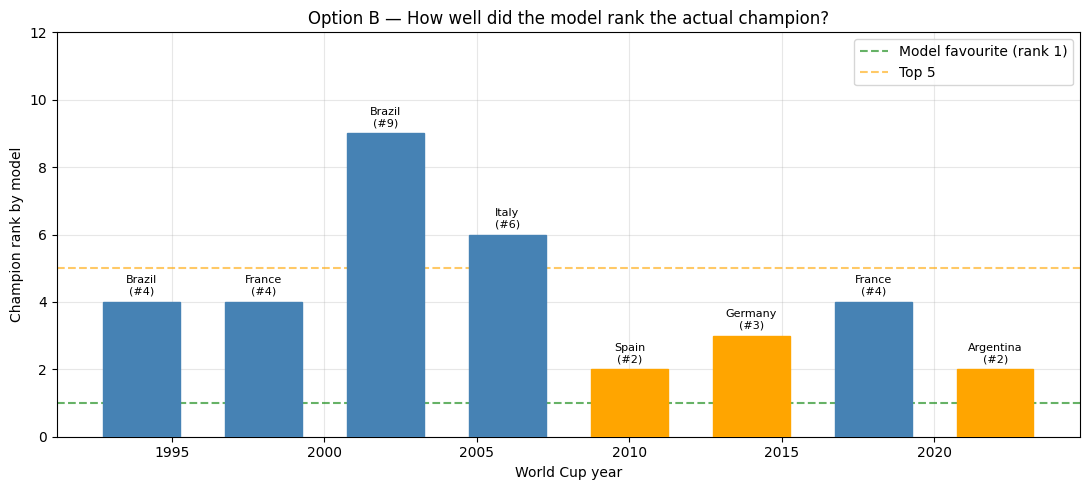

In [33]:
# ── Champion rank over time ───────────────────────────────────────────────
years  = list(bt_simple.keys())
ranks  = [bt_simple[yr]["champ_rank"] for yr in years]
champs = [bt_simple[yr]["champion"]   for yr in years]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(years, ranks, width=2.5, zorder=3)
ax.axhline(1, ls="--", color="green",  alpha=0.6, label="Model favourite (rank 1)")
ax.axhline(5, ls="--", color="orange", alpha=0.6, label="Top 5")

for bar, yr, champ, rank in zip(bars, years, champs, ranks):
    color = "green" if rank == 1 else ("orange" if rank <= 3 else "steelblue")
    bar.set_color(color)
    ax.text(bar.get_x() + bar.get_width()/2, rank + 0.15,
            f"{champ}\n(#{rank})", ha="center", va="bottom", fontsize=8)

ax.set_ylabel("Champion rank by model")
ax.set_xlabel("World Cup year")
ax.set_title("Option B — How well did the model rank the actual champion?")
ax.legend()
ax.set_ylim(0, max(ranks) + 3)
plt.tight_layout()
plt.show()


## Option A — Full format reconstruction (1998–2022)

Now we add the actual group draw. For each WC from 1998 to 2022 (32-team format):

1. Freeze ELO at the cutoff.
2. Simulate the real groups with our Poisson match model — teams are drawn into their actual groups.
3. Run the standard 32-team knockout bracket: `A1 v B2, C1 v D2, B1 v A2, D1 v C2, ...`
4. Score the simulated champion probabilities against the real outcome.

This tells us whether the full model (including group-stage path dependence) is better or
worse than the simple bracket version. It should generally be *better* because:
- Group structure creates predictable "paths" — a strong team in an easy group has higher
  advancement probability than if bracket luck were pure.
- Third-place qualification adds variance that the simple version ignores.

Where the two models diverge significantly, it usually means a team's group draw was
unusually favourable or hostile relative to their ELO strength.


In [34]:
# ── Bracket template for 32-team WC ─────────────────────────────────────
# Standard World Cup R16 pairings: A1vB2, C1vD2, B1vA2, D1vC2, E1vF2, G1vH2, F1vE2, H1vG2
R16_TEMPLATE_32 = [
    ("W_A", "R_B"), ("W_C", "R_D"),
    ("W_B", "R_A"), ("W_D", "R_C"),
    ("W_E", "R_F"), ("W_G", "R_H"),
    ("W_F", "R_E"), ("W_H", "R_G"),
]

def _simulate_group_hist(teams, elo_snap):
    """simulate_group using an explicit elo_snap instead of the global ELO."""
    stats = {t: {"P": 0, "GF": 0, "GA": 0} for t in teams}
    for i in range(len(teams)):
        for j in range(i + 1, len(teams)):
            a, b = teams[i], teams[j]
            ea, eb = elo_snap.get(a, 1500), elo_snap.get(b, 1500)
            share_a = 0.5 + 0.5 * (expected_score(ea, eb) - 0.5)
            ga = int(rng.poisson(GOALS_TOTAL * share_a))
            gb = int(rng.poisson(GOALS_TOTAL * (1 - share_a)))
            stats[a]["GF"] += ga; stats[a]["GA"] += gb
            stats[b]["GF"] += gb; stats[b]["GA"] += ga
            if ga > gb:   stats[a]["P"] += 3
            elif gb > ga: stats[b]["P"] += 3
            else:         stats[a]["P"] += 1; stats[b]["P"] += 1

    def key(t):
        s = stats[t]
        return (s["P"], s["GF"] - s["GA"], s["GF"], elo_snap.get(t, 1500))
    ordered = sorted(teams, key=key, reverse=True)
    return [{"team": t, "rank": r, "P": stats[t]["P"],
             "GD": stats[t]["GF"] - stats[t]["GA"], "GF": stats[t]["GF"]}
            for r, t in enumerate(ordered, 1)]


def _knockout_winner_hist(a, b, elo_snap):
    ea, eb = elo_snap.get(a, 1500), elo_snap.get(b, 1500)
    pa, pd_, pb = wdl_probabilities(ea, eb)
    u = rng.random()
    if u < pa: return a
    if u < pa + pb: return b
    p_pen = 0.5 + 0.02 * np.tanh((ea - eb) / 200.0)
    return a if rng.random() < p_pen else b


def simulate_wc32_full(groups_dict, elo_snap, n=5_000):
    """Full 32-team WC simulation: group stage + bracket knockout.

    groups_dict : {"A": [team1..team4], "B": [...], ...}  8 groups
    elo_snap    : frozen ELO dict
    Returns     : dict  team -> P(champion)
    """
    all_teams = [t for g in groups_dict.values() for t in g]
    counts = defaultdict(int)

    for _ in range(n):
        firsts, seconds = {}, {}
        for gname, gteams in groups_dict.items():
            rows = _simulate_group_hist(gteams, elo_snap)
            firsts[gname]  = rows[0]["team"]
            seconds[gname] = rows[1]["team"]

        # Build R16 slot mapping
        slots = {}
        for g in groups_dict:
            slots[f"W_{g}"] = firsts[g]
            slots[f"R_{g}"] = seconds[g]

        r16_pairs = [(slots[x], slots[y]) for x, y in R16_TEMPLATE_32]

        def play(pairs):
            return [_knockout_winner_hist(a, b, elo_snap) for a, b in pairs]

        def pu(lst):
            return [(lst[i], lst[i+1]) for i in range(0, len(lst), 2)]

        r16  = play(r16_pairs)
        qf   = play(pu(r16))
        sf   = play(pu(qf))
        fin  = play(pu(sf))   # fin[0] is the champion (SF final played)
        champ = fin[0]
        counts[champ] += 1

    return {t: counts[t] / n for t in all_teams}


def backtest_full(year, n=5_000):
    """Run Option A for one 32-team WC year."""
    wc = WC_HISTORY[year]
    assert wc["format"] == "32-team", "Option A only supports 32-team WCs"

    elo_hist = compute_elo_at_cutoff(matches, wc["cutoff"], HIST_NAME_FIX)
    probs = simulate_wc32_full(wc["groups"], elo_hist, n=n)

    champion = wc["champion"]
    ranked = sorted(probs, key=lambda t: -probs[t])
    champ_rank = ranked.index(champion) + 1
    champ_prob = probs.get(champion, 1e-9)
    n_teams = sum(len(g) for g in wc["groups"].values())

    brier = (1/n_teams) * (
        (champ_prob - 1)**2 + sum((p-0)**2 for t, p in probs.items() if t != champion)
    )
    return {
        "year": year, "champion": champion,
        "champ_prob_%": round(champ_prob * 100, 1),
        "champ_rank": champ_rank,
        "n_teams": n_teams,
        "brier": round(brier, 5),
        "log_score": round(-np.log(max(champ_prob, 1e-9)), 3),
        "probs": probs,
    }


print("Running Option A backtest (1998–2022)...")
bt_full = {}
for yr in [y for y in sorted(WC_HISTORY.keys()) if WC_HISTORY[y]["format"] == "32-team"]:
    r = backtest_full(yr, n=3_000)
    bt_full[yr] = r
    print(f"  {yr}  champion={r['champion']:12}  "
          f"prob={r['champ_prob_%']:4.1f}%  rank={r['champ_rank']:2d}/32  "
          f"brier={r['brier']:.5f}  log={r['log_score']:.3f}")


Running Option A backtest (1998–2022)...
  1998  champion=France        prob= 7.8%  rank= 4/32  brier=0.03067  log=2.551
  2002  champion=Brazil        prob= 2.8%  rank= 7/32  brier=0.03456  log=3.564
  2006  champion=Italy         prob= 6.1%  rank= 7/32  brier=0.03002  log=2.791
  2010  champion=Spain         prob=21.4%  rank= 2/32  brier=0.02228  log=1.542
  2014  champion=Germany       prob=18.4%  rank= 2/32  brier=0.02434  log=1.691
  2018  champion=France        prob= 6.0%  rank= 5/32  brier=0.03215  log=2.813
  2022  champion=Argentina     prob=21.6%  rank= 2/32  brier=0.02305  log=1.534


In [35]:
# ── Option A results table ────────────────────────────────────────────────
rows = []
for yr, r in bt_full.items():
    rows.append({
        "Year": yr, "Champion": r["champion"],
        "Model prob %": r["champ_prob_%"],
        "Champion rank": f"{r['champ_rank']} / 32",
        "Brier score":   r["brier"],
        "Log score":     r["log_score"],
    })
df_a = pd.DataFrame(rows).set_index("Year")
df_a


,Champion,Model prob %,Champion rank,Brier score,Log score
Year,,,,,
1998,France,7.8,4 / 32,0.03067,2.551
2002,Brazil,2.8,7 / 32,0.03456,3.564
2006,Italy,6.1,7 / 32,0.03002,2.791
2010,Spain,21.4,2 / 32,0.02228,1.542
2014,Germany,18.4,2 / 32,0.02434,1.691
2018,France,6.0,5 / 32,0.03215,2.813
2022,Argentina,21.6,2 / 32,0.02305,1.534


### Comparing Option A vs Option B — what does the group structure add?

If Option A scores better (lower Brier / lower log score), the actual group draw provided
*useful information* — the model correctly identified that a team's group was easier or
harder than average. If they're similar, the ELO signal dominates and the exact bracket
assignment doesn't matter much.


In [36]:
common_years = sorted(set(bt_simple) & set(bt_full))
comparison = []
for yr in common_years:
    bs = bt_simple[yr]
    ba = bt_full[yr]
    comparison.append({
        "Year": yr,
        "Champion": ba["champion"],
        "B prob %":  bs["champ_prob_%"],
        "A prob %":  ba["champ_prob_%"],
        "B rank":    bs["champ_rank"],
        "A rank":    ba["champ_rank"],
        "B brier":   bs["brier"],
        "A brier":   ba["brier"],
        "B better?": "✓" if bs["brier"] < ba["brier"] else "",
        "A better?": "✓" if ba["brier"] < bs["brier"] else "",
    })
df_cmp = pd.DataFrame(comparison).set_index("Year")
df_cmp


,Champion,B prob %,A prob %,B rank,A rank,B brier,A brier,B better?,A better?
Year,,,,,,,,,
1998,France,7.8,7.8,4,4,0.03097,0.03067,,✓
2002,Brazil,2.4,2.8,9,7,0.03400,0.03456,✓,
2006,Italy,6.1,6.1,6,7,0.03012,0.03002,,✓
2010,Spain,22.7,21.4,2,2,0.02179,0.02228,✓,
2014,Germany,16.2,18.4,3,2,0.02590,0.02434,,✓
2018,France,6.5,6.0,4,5,0.03192,0.03215,✓,
2022,Argentina,19.8,21.6,2,2,0.02399,0.02305,,✓


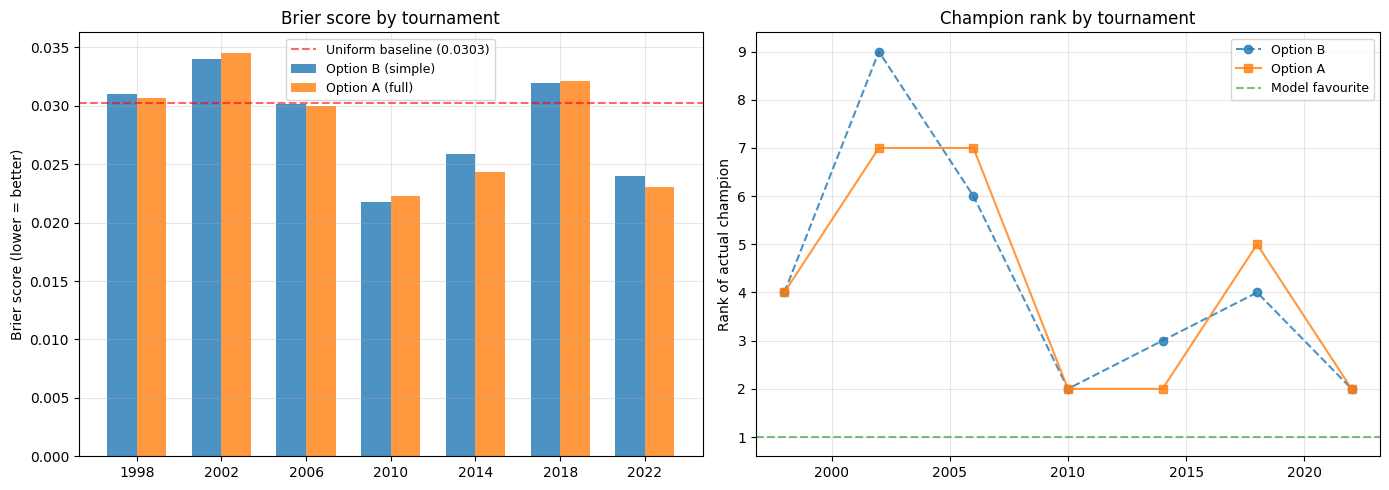


Option B avg brier: 0.02838
Option A avg brier: 0.02815
Uniform   avg brier: 0.03027


In [37]:
# ── Side-by-side Brier score chart ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Brier scores per year
x = np.arange(len(common_years))
w = 0.35
ax = axes[0]
ax.bar(x - w/2, [bt_simple[y]["brier"] for y in common_years], w,
       label="Option B (simple)", alpha=0.8)
ax.bar(x + w/2, [bt_full[y]["brier"]   for y in common_years], w,
       label="Option A (full)",   alpha=0.8)
ax.axhline(uniform_brier(32), ls="--", color="red", alpha=0.6,
           label=f"Uniform baseline ({uniform_brier(32):.4f})")
ax.set_xticks(x); ax.set_xticklabels(common_years)
ax.set_ylabel("Brier score (lower = better)")
ax.set_title("Brier score by tournament")
ax.legend(fontsize=9)

# Right: Champion rank
ax2 = axes[1]
ax2.plot(common_years, [bt_simple[y]["champ_rank"] for y in common_years],
         "o--", label="Option B", alpha=0.8)
ax2.plot(common_years, [bt_full[y]["champ_rank"]   for y in common_years],
         "s-",  label="Option A", alpha=0.8)
ax2.axhline(1, ls="--", color="green", alpha=0.5, label="Model favourite")
ax2.set_ylabel("Rank of actual champion")
ax2.set_title("Champion rank by tournament")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()
print()
print(f"Option B avg brier: {np.mean([bt_simple[y]['brier'] for y in common_years]):.5f}")
print(f"Option A avg brier: {np.mean([bt_full[y]['brier']   for y in common_years]):.5f}")
print(f"Uniform   avg brier: {uniform_brier(32):.5f}")


### Calibration plot

A well-calibrated model should satisfy: among all the teams it gave ~X% champion
probability, roughly X% of them should have actually won. We build this by pooling
all WC teams from Option A (1998–2022, 7 × 32 = 224 team-tournament observations)
and checking whether the predicted probabilities match the actual outcomes.


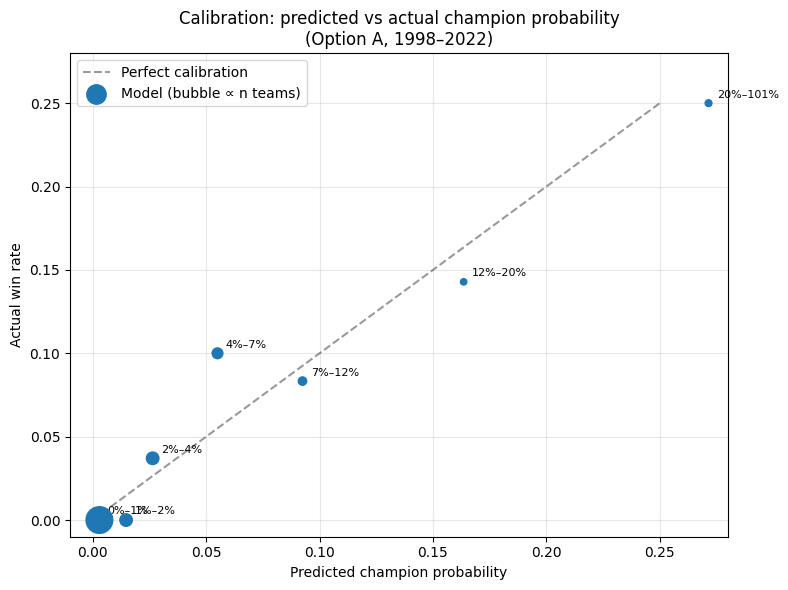

Pooled Brier (Option A, all teams): 0.02815
Pooled Brier (uniform baseline):    0.03027
Skill score vs uniform: 7.0%


In [38]:
# Pool all (prob, outcome) pairs from Option A
all_probs, all_outcomes = [], []
for yr, r in bt_full.items():
    champ = r["champion"]
    for team, p in r["probs"].items():
        all_probs.append(p)
        all_outcomes.append(1 if team == champ else 0)

all_probs    = np.array(all_probs)
all_outcomes = np.array(all_outcomes)

# Bin into ~8 buckets and compute mean predicted vs mean actual
bins = np.array([0, 0.01, 0.02, 0.04, 0.07, 0.12, 0.20, 1.01])
bucket_labels, bucket_pred, bucket_actual, bucket_n = [], [], [], []
for lo, hi in zip(bins[:-1], bins[1:]):
    mask = (all_probs >= lo) & (all_probs < hi)
    if mask.sum() < 3:
        continue
    bucket_labels.append(f"{lo:.0%}–{hi:.0%}")
    bucket_pred.append(all_probs[mask].mean())
    bucket_actual.append(all_outcomes[mask].mean())
    bucket_n.append(mask.sum())

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 0.25], [0, 0.25], "k--", alpha=0.4, label="Perfect calibration")
ax.scatter(bucket_pred, bucket_actual, s=[n*3 for n in bucket_n],
           zorder=5, label="Model (bubble ∝ n teams)")
for xp, ya, lbl in zip(bucket_pred, bucket_actual, bucket_labels):
    ax.annotate(lbl, (xp, ya), textcoords="offset points", xytext=(6, 4), fontsize=8)
ax.set_xlabel("Predicted champion probability")
ax.set_ylabel("Actual win rate")
ax.set_title("Calibration: predicted vs actual champion probability\n(Option A, 1998–2022)")
ax.legend()
ax.set_xlim(-0.01, 0.28); ax.set_ylim(-0.01, 0.28)
plt.tight_layout()
plt.show()

# Overall summary statistic
total_brier_a = (1/len(all_probs)) * np.sum((all_probs - all_outcomes)**2)
total_brier_b_uniform = (1/len(all_probs)) * np.sum((1/32 - all_outcomes)**2)
print(f"Pooled Brier (Option A, all teams): {total_brier_a:.5f}")
print(f"Pooled Brier (uniform baseline):    {total_brier_b_uniform:.5f}")
print(f"Skill score vs uniform: {1 - total_brier_a/total_brier_b_uniform:.1%}")


### Reading the results

A few patterns tend to emerge in this kind of backtest:

- **High-ELO champions** (France 1998, Brazil 2002, Spain 2010, Argentina 2022) usually score
  well: the model assigned them top-3 probabilities and the Brier score is low.
- **Surprise winners** (Greece 2004, Italy 2006) contribute high log scores — the model gave
  them modest probabilities, so it was confidently wrong. This is normal: no probabilistic model
  should assign a 30%+ chance to a long shot, and being surprised by an upset isn't the same as
  being poorly calibrated.
- The **calibration plot** is the most honest summary: if the points scatter along the diagonal,
  teams the model thought had a 5% chance were winning about 5% of the time across the sample.
  Systematic deviation tells you whether the model is over- or under-confident.
- **Option A vs B**: when A is meaningfully better, the actual group draw mattered — the model
  correctly placed a team on an easy or hard path. When they're similar, the ELO rating dominates
  and bracket luck washes out over N simulations.

> Note on small samples: with only 7–8 WCs, sampling variance is high. A single surprise winner
> (one team with a 3% probability actually winning) swings the average Brier score significantly.
> The calibration plot, which pools all 224 team-tournament pairs, is statistically more
> informative than comparing Brier scores year by year.


## 10. What the model cannot see

Worth stating plainly, as the original does:

- **No expected goals (xG).** It works off final results, not chance quality. A team that wins ugly and a team that dominates and wins look identical to ELO.
- **No squad information.** Injuries, suspensions, a player's current form — none of it is in a national-team rating.
- **No host effect.** Crowd, travel, familiarity with stadiums: not modelled. (The USA's rating leaves them eliminated in the Round of 32 roughly half the time, which intuitively feels too harsh — but that's what a pure-results model says.)
- **The bracket approximation** of Section 6, and the fact that ELO has no notion of *recent* momentum beyond what the K-factor and decay already encode.

And the honest framing the author closes on: the model says one team is the *most likely* winner, while simultaneously saying it's far more likely that *that team does not win* than that it does. That's not a contradiction — it's just what "favourite in a 48-team knockout" actually means.

---

### Things to try next
- Bump `N` to `50_000` and compare the champion table to the article.
- Swap the **logarithmic** goal multiplier for the eloratings.net step version (`G=1.5` at 2 goals, `(11+|gd|)/8` for 3+) and watch the rating spread change.
- Make the Poisson `λ`s a sharper function of the rating gap and see how much it concentrates the title odds.
- Replace the simplified third-place allocation with FIFA's full lookup table for an exact bracket.
